# Actividad 3 | Aplicar algoritmos de aprendizaje supervisado con PySpark

**Instituto Tecnológico y de Estudios Superiores de Monterrey**  
**Maestría en Inteligencia Artificial Aplicada**  
**Análisis de grandes volúmenes de datos**  
**Docente:** Dr. Iván Olmos Pineda

* Palma Palacios, Christian Ricardo — A01686081

**Fecha:** 24 de mayo de 2026

## 1. Introducción Teórica

El aprendizaje supervisado es una rama del Machine Learning en la cual un modelo aprende a partir de un conjunto de datos etiquetados. Cada instancia de entrenamiento contiene variables de entrada (features) y una variable objetivo (label), permitiendo que el algoritmo identifique patrones y relaciones entre los datos para posteriormente realizar predicciones sobre nuevos registros.

### 1.1 Algoritmos representativos de aprendizaje supervisado en Big Data
Apache Spark MLlib proporciona implementaciones distribuidas de múltiples algoritmos de aprendizaje supervisado, optimizados para ambientes de Big Data. Entre los más representativos se encuentran:

**a) Decision Tree**
El algoritmo Decision Tree construye un árbol de decisiones mediante divisiones sucesivas de los datos según las variables que mejor separan las clases.

**b) Random Forest**
El algoritmo Random Forest es un método ensamblado (ensemble learning) que combina múltiples árboles de decisión generados aleatoriamente para mejorar la precisión y reducir el sobreajuste.

**c) GBTClassifier (Gradient Boosted Trees)**
El algoritmo Gradient Boosted Trees construye árboles secuencialmente, donde cada nuevo árbol corrige los errores cometidos por los anteriores.

**d) Multilayer Perceptron**
El Multilayer Perceptron (MLP) es una red neuronal artificial compuesta por capas de neuronas interconectadas.

**e) Linear Regression**
La Linear Regression es un algoritmo de regresión que modela la relación lineal entre variables independientes y una variable dependiente continua.

###1.2. Aprendizaje supervisado distribuido con PySpark
PySpark MLlib es la biblioteca de Machine Learning de Apache Spark que permite ejecutar algoritmos de aprendizaje supervisado de manera distribuida sobre clústeres de procesamiento.

###1.3. Relación con el proyecto desarrollado
En el presente proyecto se trabaja con un conjunto de datos de ciberseguridad compuesto por millones de registros provenientes de eventos e incidentes detectados por sistemas Microsoft Defender.

Debido al gran volumen de información, se utiliza PySpark como plataforma de procesamiento distribuido para:
- Realizar limpieza y transformación de datos.
- Construir particiones y muestras representativas.
- Entrenar modelos de clasificación supervisada.
- Evaluar el desempeño de los algoritmos.
- Escalar el procesamiento a grandes volúmenes de datos.

Los algoritmos supervisados seleccionados permiten identificar patrones de comportamiento asociados a incidentes de seguridad y facilitan la automatización de tareas de clasificación dentro de entornos de ciberseguridad empresarial.

###1.4. Algoritmos recomendados para el proyecto

**1. Random Forest Classifier**
Debido al volumen y complejidad de los eventos de ciberseguridad, Random Forest permite capturar patrones complejos sin requerir demasiada preparación matemática de los datos. Además, PySpark distribuye el entrenamiento entre múltiples nodos, permitiendo procesar millones de registros eficientemente.

**2. Decision Tree Classifier** Soporta clasificación multiclase de forma nativa y resulta más adecuado para el contexto del proyecto de ciberseguridad. Sirve como baseline, permite interpretar reglas y comparar complejidad vs desempeño.

##2. Selección de los datos

A continuación, se instalan las dependencias necesarias para ejecutar PySpark en el entorno de Google Colab.

In [64]:
# Instalación de Java y descarga de Spark
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

In [65]:
# Configuración de variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [66]:
# Inicialización de la sesión de Spark
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BigData_Particionamiento") \
    .getOrCreate()

# Habilitar formato de salida mejorado para DataFrames
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

Se monta la unidad de Google Drive y se carga el archivo CSV en un DataFrame de PySpark.

In [67]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir ruta del archivo
file_path = "/content/drive/MyDrive/Colab Notebooks/MNA/BigData/ProyectoEtapa1/Microsoft_GUIDE_Train.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
# Cargar el dataset
df = spark.read.csv(file_path, header=True, sep=",", inferSchema=True)

# Mostrar las primeras 2 filas para verificar la carga
df.limit(2).toPandas()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04 06:05:15,7,6,InitialAccess,None,TruePositive,...,None,None,5,66,None,None,None,31,6,3
1,455266534868,88,326,210035,2024-06-14 03:01:25,58,43,Exfiltration,None,FalsePositive,...,None,None,5,66,None,None,None,242,1445,10630


**Preprocesamiento**

Asegurar la calidad de los datos antes del particionamiento (muestreo) y antes del aprendizaje supervisado.

In [69]:
from pyspark.sql.functions import col, when, count, lit

# Eliminar registros sin variable objetivo
df = df.filter(col("IncidentGrade").isNotNull())

# Eliminar duplicados
df = df.dropDuplicates()

# Eliminar columnas >90% NULL
cols_to_drop = [
    "ActionGrouped",
    "ActionGranular",
    "EmailClusterId",
    "ResourceType",
    "Roles",
    "AntispamDirection",
    "ThreatFamily"
]
df = df.drop(*cols_to_drop)

# Imputar variables moderadamente incompletas
fill_values = {
    "MitreTechniques": "Unknown",
    "SuspicionLevel": "Unknown",
    "LastVerdict": "Unknown"
}
df = df.fillna(fill_values)

# Extraer variables temporales
from pyspark.sql.functions import hour, dayofweek, month
df = df.withColumn("EventHour", hour(col("Timestamp")))
df = df.withColumn("EventDayOfWeek", dayofweek(col("Timestamp")))
df = df.withColumn("EventMonth", month(col("Timestamp")))

In [70]:
# Reducir cardinalidad (Top-15) para aprendizaje supervisado
top_categories = [
    row["Category"]
    for row in df.groupBy("Category")
    .count()
    .orderBy(col("count").desc())
    .limit(15)
    .collect()
]

df = df.withColumn(
    "CategoryReduced",
    when(
        col("Category").isin(top_categories),
        col("Category")
    ).otherwise("OtherCategory")
)

In [71]:
# Obtener cantidad total de registros limpios
total_records = df.count()
print(f"Cantidad total de registros limpios: {total_records:,}")

Cantidad total de registros limpios: 9,442,956


**Muestreo**

Para evitar una explosión combinatoria y estratos demasiado pequeños, se aplica una estrategia de agrupación *Top-N* sobre las variables categóricas de mayor cardinalidad.

In [72]:
# Agrupación de la variable Category (Top 7)
top_categories = [
    "InitialAccess",
    "Exfiltration",
    "SuspiciousActivity",
    "CommandAndControl",
    "Impact",
    "CredentialAccess",
    "Execution"
]
df = df.withColumn(
    "CategoryGroup",
    when(col("Category").isin(top_categories), col("Category"))
    .otherwise("OtherCategory")
)

# Agrupación de la variable EntityType (Top 2)
df = df.withColumn(
    "EntityTypeGroup",
    when(col("EntityType") == "Ip", "Ip")
    .when(col("EntityType") == "User", "User")
    .otherwise("Other")
)

Se definen las columnas que conformarán las reglas de particionamiento.

In [73]:
# Definir columnas de particionamiento
partition_columns = [
    "IncidentGrade",
    "CategoryGroup",
    "EntityTypeGroup",
    "EvidenceRole"
]

Muestreo estratificado proporcional sin reemplazo, utilizando como estratos las combinaciones observadas empíricamente de las variables IncidentGrade, CategoryGroup, EntityTypeGroup y EvidenceRole

In [74]:
from pyspark.sql.functions import concat_ws

# =====================================================
# 1. Crear columna estrato (partición)
# =====================================================

df = df.withColumn(
    "Stratum",
    concat_ws(
        "_",
        col("IncidentGrade"),
        col("CategoryGroup"),
        col("EntityTypeGroup"),
        col("EvidenceRole")
    )
)

# =====================================================
# 2. Obtener lista de estratos observados
# =====================================================

strata_df = df.select("Stratum").distinct()

strata_list = [row["Stratum"] for row in strata_df.collect()]

print(f"Número de estratos observados: {len(strata_list)}")

# =====================================================
# 3. Definir fracción de muestreo por estrato
# =====================================================

sample_fraction = 0.10

fractions = {
    stratum: sample_fraction
    for stratum in strata_list
}

# =====================================================
# 4. Extraer muestra estratificada M
# =====================================================

seed_value = 42

sample_M = df.sampleBy(
    "Stratum",
    fractions=fractions,
    seed=seed_value
)

# =====================================================
# 5. Persistir M en memoria
# =====================================================

# Cache en memoria RAM y Disco
sample_M = sample_M.cache()
# Materializar cache UNA sola vez
_ = sample_M.count()

# =====================================================
# 6. Verificar tamaño de muestra
# =====================================================

sample_count = sample_M.count()

print(f"Total registros dataset original: {total_records:,}")
print(f"Total registros muestra M: {sample_count:,}")
print(f"Porcentaje real: {(sample_count/total_records)*100:.4f}%")

Número de estratos observados: 115
Total registros dataset original: 9,442,956
Total registros muestra M: 944,874
Porcentaje real: 10.0061%


Verificación de representatividad. La muestra mantiene aproximadamente las proporciones originales.

In [75]:
# Distribución original
original_distribution = df.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "OriginalCount")

# Distribución de la muestra
sample_distribution = sample_M.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "SampleCount")

# Comparación
comparison = original_distribution.join(
    sample_distribution,
    on=partition_columns,
    how="left"
)

comparison = comparison.fillna(0)
comparison = comparison.withColumn(
    "SamplePct",
    (col("SampleCount") / col("OriginalCount")) * 100
)
comparison.orderBy(col("OriginalCount").desc()).show(3, truncate=False)

+--------------+-------------+---------------+------------+-------------+-----------+------------------+
|IncidentGrade |CategoryGroup|EntityTypeGroup|EvidenceRole|OriginalCount|SampleCount|SamplePct         |
+--------------+-------------+---------------+------------+-------------+-----------+------------------+
|TruePositive  |InitialAccess|Other          |Related     |920775       |92327      |10.027096739159946|
|BenignPositive|Exfiltration |Other          |Impacted    |823594       |82394      |10.004201099085229|
|TruePositive  |InitialAccess|Ip             |Related     |602878       |60187      |9.98328019931064  |
+--------------+-------------+---------------+------------+-------------+-----------+------------------+
only showing top 3 rows



**Submuestreo**

Construcción de una muestra M' para evitar que los tiempos de procesamiento sean altos. M' será un subconjunto de M.
Se aplicará nuevamente el muestreo estratificado proporcional sin reemplazo
utilizando los mismos estratos definidos previamente.

In [150]:
# Definir fracción de reducción
sample_fraction_M_prime = 0.003

# Verificar tamaño actual de M
M_count = sample_count

# =====================================================
# Definir fracciones por estrato
# =====================================================

fractions_M_prime = {
    stratum: sample_fraction_M_prime
    for stratum in strata_list
}

# =====================================================
# Extraer muestra M'
# =====================================================

seed_value = 42

M_prime = sample_M.sampleBy(
    "Stratum",
    fractions=fractions_M_prime,
    seed=seed_value
)

# =====================================================
# Persistir M' en memoria
# =====================================================

# Cache en memoria RAM y Disco
M_prime = M_prime.cache()
# Materializar cache UNA sola vez
_ = M_prime.count()

# =====================================================
# Verificar tamaño
# =====================================================

M_prime_count = M_prime.count()

print(f"Registros en M: {M_count:,}")
print(f"Registros en M': {M_prime_count:,}")
print(f"Porcentaje respecto a M: {(M_prime_count/M_count)*100:.4f}%")

Registros en M: 944,874
Registros en M': 2,821
Porcentaje respecto a M: 0.2986%


Verificación de representatividad de M'

In [151]:
# Distribución en M'
dist_M_prime = M_prime.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "Count_M_prime")

# Distribución en M
dist_M = sample_M.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "Count_M")

# Comparación
comparison_M = dist_M.join(
    dist_M_prime,
    on=partition_columns,
    how="left"
)
comparison_M = comparison_M.fillna(0)
comparison_M = comparison_M.withColumn(
    "Pct_M_prime",
    (col("Count_M_prime") / col("Count_M")) * 100
)
comparison_M.orderBy(col("Count_M").desc()).show(3, truncate=False)

+--------------+-------------+---------------+------------+-------+-------------+-------------------+
|IncidentGrade |CategoryGroup|EntityTypeGroup|EvidenceRole|Count_M|Count_M_prime|Pct_M_prime        |
+--------------+-------------+---------------+------------+-------+-------------+-------------------+
|TruePositive  |InitialAccess|Other          |Related     |92327  |257          |0.2783584433589308 |
|BenignPositive|Exfiltration |Other          |Impacted    |82394  |250          |0.3034201519528121 |
|TruePositive  |InitialAccess|Ip             |Related     |60187  |153          |0.25420771927492647|
+--------------+-------------+---------------+------------+-------+-------------+-------------------+
only showing top 3 rows



##3. Preparación del conjunto de entrenamiento, validación y prueba

Una vez construida la muestra reducida M', el siguiente paso consiste en dividirla en subconjuntos de:

- Entrenamiento (Training Set)
- Validación (Validation Set)
- Prueba (Test Set)

Dado que la variable objetivo "IncidentGrade" presenta una distribución desbalanceada:

| Clase          | Distribución |
| -------------- | ------------ |
| BenignPositive | 43.5%        |
| TruePositive   | 35.0%        |
| FalsePositive  | 21.5%        |

La técnica más adecuada es muestreo estratificado proporcional sin reemplazo. El muestreo estratificado permite:
- Preservar la distribución original de las clases.
- Evitar sesgos estadísticos.
- Reducir el riesgo de sobre-representar clases mayoritarias.
- Asegurar que entrenamiento, validación y prueba contengan ejemplos de todas las categorías.

Si se utilizara muestreo aleatorio simple puro, podrían generarse subconjuntos con distribuciones desbalanceadas, afectando negativamente el entrenamiento,
la evaluación y la capacidad de generalización del modelo.

La división recomendada es:

| Conjunto      | Porcentaje | Objetivo                  |
| ------------- | ---------- | ------------------------- |
| Entrenamiento | 70%        | Aprendizaje del modelo    |
| Validación    | 15%        | Ajuste de hiperparámetros |
| Prueba        | 15%        | Evaluación final          |


In [152]:
# Verificar distribución original
M_prime.groupBy("IncidentGrade").count().show()

+--------------+-----+
| IncidentGrade|count|
+--------------+-----+
|BenignPositive| 1268|
| FalsePositive|  601|
|  TruePositive|  952|
+--------------+-----+



**División estratificada**.
PySpark no posee una función directa de división estratificada múltiple, por lo que una técnica podría consistir en dividir cada clase individualmente y luego unir resultados, pero sería costoso compuntacionalmente.

**Estrategia optimizada recomendada**.
La mejor práctica en PySpark es usar una columna aleatoria controlada y dividir directamente preservando estratos mediante rand(seed), esto reduce drásticamente el tiempo de procesamiento.

**Ventaja clave**. M_prime tiene la distribución correcta de "IncidentGrade", no se necesita dividir clase por clase. Basta con mezclar aleatoriamente y
dividir proporcionalmente, la distribución estadística se conservará naturalmente debido al tamaño de M'.

In [153]:
from pyspark.sql.functions import rand

# =====================================================
# Agregar columna aleatoria reproducible
# =====================================================

seed_value = 42

M_prime_random = M_prime.withColumn(
    "random",
    rand(seed_value)
)

# =====================================================
# División Train / Validation / Test
# =====================================================

# Dividir:
# 70% entrenamiento
# 15% validación
# 15% prueba

train_df = M_prime_random.filter(col("random") < 0.70)

val_df = M_prime_random.filter(
    (col("random") >= 0.70) &
    (col("random") < 0.85)
)

test_df = M_prime_random.filter(col("random") >= 0.85)

# =====================================================
# Remover columna auxiliar
# =====================================================

train_df = train_df.drop("random")
val_df = val_df.drop("random")
test_df = test_df.drop("random")

# Persistir subconjuntos
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

# Verificación eficiente
print({
    "TRAIN": train_df.count(),
    "VALIDATION": val_df.count(),
    "TEST": test_df.count()
})

{'TRAIN': 1950, 'VALIDATION': 439, 'TEST': 432}


Verificación de distribución de clases

In [154]:
# Entrenamiento
print("\n==========")
print("TRAIN")
print("==========")
train_df.groupBy("IncidentGrade").count().show()
# Validación
print("\n==========")
print("VALIDATION")
print("==========")
val_df.groupBy("IncidentGrade").count().show()
# Prueba
print("\n==========")
print("TEST")
print("==========")
test_df.groupBy("IncidentGrade").count().show()



TRAIN
+--------------+-----+
| IncidentGrade|count|
+--------------+-----+
|BenignPositive|  875|
| FalsePositive|  426|
|  TruePositive|  649|
+--------------+-----+


VALIDATION
+--------------+-----+
| IncidentGrade|count|
+--------------+-----+
| FalsePositive|   95|
|  TruePositive|  155|
|BenignPositive|  189|
+--------------+-----+


TEST
+--------------+-----+
| IncidentGrade|count|
+--------------+-----+
|BenignPositive|  204|
|  TruePositive|  148|
| FalsePositive|   80|
+--------------+-----+



##4. Construcción de modelos de aprendizaje supervisado

En esta etapa se implementarán dos algoritmos supervisados disponibles en PySpark:
- Random Forest Classifier
- Decision Tree Classifier

Estos algoritmos son apropiados porque:
- Soportan variables categóricas y numéricas.
- Manejan relaciones no lineales.
- Son robustos frente al ruido.
- Escalan adecuadamente en ambientes Big Data.

Por tratarse de un problema multiclase y parcialmente desbalanceado, se utilizarán métricas de:
- Accuracy
- Precision
- Recall
- F1-Score

Además, se evaluará el riesgo de:
- Sobreentrenamiento (Overfitting)
- Subentrenamiento (Underfitting)

Estrategia recomendada (PySpark ML)
- Preparación de variables.
- Indexación de variables categóricas.
- Construcción del vector de features.
- Entrenamiento del modelo.
- Predicción.
- Evaluación sobre: entrenamiento, validación.
- Generación de classification_report().

###4.1 Preparación de variables

Variables predictoras recomendadas. No se deben utilizar las variables agrupadas usadas en el muestreo (Top-7 y Top-2).

In [155]:
# =====================================================
# Variables categóricas
# =====================================================

categorical_cols = [
    # SOC context:
    "CategoryReduced",
    "MitreTechniques",
    "EntityType",
    "EvidenceRole",
    "SuspicionLevel",
    "LastVerdict",
    # Organizational_
    #"OrgId",
    #"DetectorId",
    # Geographic:
    #"CountryCode",
]

# =====================================================
# Variables numéricas
# =====================================================

numeric_cols = [
    "EventHour",
    "EventDayOfWeek",
    "EventMonth"
]

Estas variables son apropiadas porque:
- Ya fueron limpiadas.
- Poseen baja cardinalidad.
- Están directamente relacionadas con eventos de ciberseguridad.

###4.2 Transformación de variables

In [156]:
from pyspark.sql.functions import col, count
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

# =====================================================
# Indexar variable objetivo
# =====================================================

label_indexer = StringIndexer(
    inputCol="IncidentGrade",
    outputCol="label"
)

# =====================================================
# FREQUENCY ENCODING
# =====================================================

# Se calcula la frecuencia relativa de cada categoría
# usando únicamente train_df para evitar data leakage.

train_freq = train_df

frequency_feature_cols = []

for c in categorical_cols:

    # ---------------------------------------------
    # Calcular frecuencias
    # ---------------------------------------------

    freq_df = train_df.groupBy(c) \
        .agg(count("*").alias(f"{c}_freq"))

    # ---------------------------------------------
    # Convertir a frecuencia relativa
    # ---------------------------------------------

    total_train = train_df.count()

    freq_df = freq_df.withColumn(
        f"{c}_freq",
        col(f"{c}_freq") / total_train
    )

    # ---------------------------------------------
    # Join con train
    # ---------------------------------------------

    train_freq = train_freq.join(
        freq_df,
        on=c,
        how="left"
    )

    # ---------------------------------------------
    # Join con validation
    # ---------------------------------------------

    val_df = val_df.join(
        freq_df,
        on=c,
        how="left"
    )

    # ---------------------------------------------
    # Join con test
    # ---------------------------------------------

    test_df = test_df.join(
        freq_df,
        on=c,
        how="left"
    )

    frequency_feature_cols.append(f"{c}_freq")

# =====================================================
# Ajustar índice de labels
# =====================================================

label_model = label_indexer.fit(train_freq)

train_freq = label_model.transform(train_freq)
val_df = label_model.transform(val_df)
test_df = label_model.transform(test_df)

# =====================================================
# Construcción del vector de features
# =====================================================

assembler = VectorAssembler(
    inputCols=frequency_feature_cols + numeric_cols,
    outputCol="features",
    handleInvalid="keep"
)

# =====================================================
# Transformación final
# =====================================================

train_prepared = assembler.transform(train_freq)

val_prepared = assembler.transform(val_df)

test_prepared = assembler.transform(test_df)

# =====================================================
# Selección final
# =====================================================

train_prepared = train_prepared.select(
    "features",
    "label"
)

val_prepared = val_prepared.select(
    "features",
    "label"
)

test_prepared = test_prepared.select(
    "features",
    "label"
)

# =====================================================
# Verificación
# =====================================================

train_prepared.select("features", "label").show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                             |label|
+-------------------------------------------------------------------------------------------------------------------------------------+-----+
|[0.44051282051282054,0.14974358974358976,0.06564102564102564,0.5584615384615385,0.8323076923076923,0.7569230769230769,6.0,1.0,6.0]   |1.0  |
|[0.09487179487179487,0.561025641025641,0.07179487179487179,0.5584615384615385,0.1676923076923077,0.15794871794871795,22.0,3.0,6.0]   |0.0  |
|[0.44051282051282054,0.016923076923076923,0.07846153846153846,0.44153846153846155,0.8323076923076923,0.7569230769230769,15.0,2.0,5.0]|2.0  |
|[0.09487179487179487,0.561025641025641,0.07179487179487179,0.5584615384615385,0.1676923076923077,0.15794871794871795,5.0,3.0,6.0]    |0.0  |
|[0.44

###4.3 Entrenamiento de modelos

Decision Tree Classifier

In [157]:
from pyspark.ml.classification import DecisionTreeClassifier

# Definir modelo
dt_model = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=10,  # Bajar para disminuir el gap
    maxBins=128,
    minInstancesPerNode = 200,
    seed=42
)

# Entrenar
dt_fitted = dt_model.fit(train_prepared)

Random Forest Classifier

In [158]:
from pyspark.ml.classification import RandomForestClassifier

# Definir modelo
rf_model = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,  # Bajar para disminuir el gap
    maxBins=128,
    minInstancesPerNode = 100,
    seed=42
)

# Entrenar
rf_fitted = rf_model.fit(train_prepared)

###4.4 Predicciones

In [159]:
# Decision Tree
dt_train_pred = dt_fitted.transform(train_prepared)
dt_val_pred = dt_fitted.transform(val_prepared)

In [160]:
# Random Forest
rf_train_pred = rf_fitted.transform(train_prepared)
rf_val_pred = rf_fitted.transform(val_prepared)

###4.5 Evaluación

In [161]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluador Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

In [162]:
# Accuracy Decision Tree
dt_train_acc = evaluator.evaluate(dt_train_pred)
dt_val_acc = evaluator.evaluate(dt_val_pred)

print("====================================")
print("DECISION TREE")
print("====================================")

print(f"Train Accuracy: {dt_train_acc:.4f}")
print(f"Validation Accuracy: {dt_val_acc:.4f}")

# Diferencia
diff_dt = abs(dt_train_acc - dt_val_acc)
print(f"Diferencia Train-Val: {diff_dt:.4f}")

# Verificación overfitting
if diff_dt < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo podría estar sobreentrenado.")

# Verificación Underfitting (accuracy > distribucion de clases)
if dt_train_acc < 0.70 and dt_val_acc < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

DECISION TREE
Train Accuracy: 0.6133
Validation Accuracy: 0.6059
Diferencia Train-Val: 0.0074
El modelo NO está sobreentrenado.
Posible subentrenamiento.


In [163]:
# Accuracy Random Forest
rf_train_acc = evaluator.evaluate(rf_train_pred)
rf_val_acc = evaluator.evaluate(rf_val_pred)

print("====================================")
print("RANDOM FOREST")
print("====================================")

print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Validation Accuracy: {rf_val_acc:.4f}")

# Diferencia
diff_rf = abs(rf_train_acc - rf_val_acc)
print(f"Diferencia Train-Val: {diff_rf:.4f}")

# Verificación overfitting
if diff_rf < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo podría estar sobreentrenado.")

# Verificación Underfitting (accuracy > distribucion de clases)
if rf_train_acc < 0.70 and rf_val_acc < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

RANDOM FOREST
Train Accuracy: 0.6133
Validation Accuracy: 0.6036
Diferencia Train-Val: 0.0097
El modelo NO está sobreentrenado.
Posible subentrenamiento.


###4.6 Reporte del mejor modelo

Luego de entrenar y validar los algoritmos de aprendizaje supervisado, se determinó que el modelo Random Forest Classifier obtuvo el mejor desempeño sobre el conjunto de validación, alcanzando el mayor valor de exactitud (accuracy) y manteniendo una diferencia menor al 3% entre entrenamiento y validación, por lo que no presenta evidencia significativa de sobreentrenamiento.

In [164]:
# Predicción sobre el conjunto de prueba
rf_test_pred = rf_fitted.transform(test_prepared)

In [165]:
# Accuracy sobre el conjunto de prueba
test_accuracy = evaluator.evaluate(rf_test_pred)

print("====================================")
print("RANDOM FOREST - TEST")
print("====================================")

print(f"Test Accuracy: {test_accuracy:.4f}")

RANDOM FOREST - TEST
Test Accuracy: 0.6319


In [166]:
# Classification Report
from sklearn.metrics import classification_report

y_true_test = rf_test_pred.select("label").toPandas()["label"]
y_pred_test = rf_test_pred.select("prediction").toPandas()["prediction"]

# Obtener nombres originales de clases
class_names = label_model.labels

print("====================================")
print("CLASSIFICATION REPORT - TEST")
print("====================================")

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=class_names
    )
)

CLASSIFICATION REPORT - TEST
                precision    recall  f1-score   support

BenignPositive       0.61      0.94      0.74       204
  TruePositive       0.69      0.55      0.61       148
 FalsePositive       0.00      0.00      0.00        80

      accuracy                           0.63       432
     macro avg       0.43      0.50      0.45       432
  weighted avg       0.53      0.63      0.56       432



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


En problemas multiclase y parcialmente desbalanceados como el presente caso de ciberseguridad, la matriz de confusión tradicional puede resultar difícil de interpretar cuando existen muchas observaciones.

Por ello, reemplazaremos la matriz clásica por la Matriz de confusión normalizada, porque permite visualizar proporciones relativas y facilita identificar:
- Clases mejor clasificadas.
- Errores más frecuentes.
- Posibles sesgos del modelo.

In [167]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión normalizada
cm_normalized = confusion_matrix(
    y_true_test,
    y_pred_test,
    normalize="true"
)

print("====================================")
print("MATRIZ DE CONFUSIÓN NORMALIZADA")
print("====================================\n")
print(cm_normalized)

MATRIZ DE CONFUSIÓN NORMALIZADA

[[0.94117647 0.05882353 0.        ]
 [0.4527027  0.5472973  0.        ]
 [0.7        0.3        0.        ]]


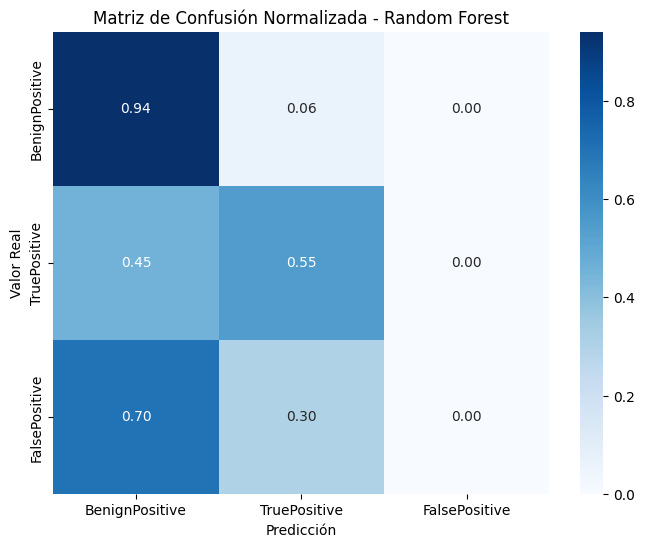

In [168]:
# Obtener nombres reales de clases
class_labels = prep_model.stages[0].labels

# Visualización de la matriz de confusión normalizada
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Matriz de Confusión Normalizada - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

**Comentarios sobre los resultados obtenidos**

**1. Evaluación general de los modelos**

Los resultados obtenidos muestran los modelos:
- Decision Tree Classifier
- Random Forest Classifier

Alcanzaron niveles de exactitud similares sobre el conjunto de validación:
| Modelo        | Train Accuracy | Validation Accuracy | Diferencia |
| ------------- | -------------- | ------------------- | ---------- |
| Decision Tree | 0.6133         | 0.6059              | 0.0074     |
| Random Forest | 0.6133         | 0.6036              | 0.0097     |

La diferencia entre entrenamiento y validación fue menor al 3% en ambos casos, por lo tanto, se concluye que los modelos NO presentan sobreentrenamiento (overfitting).

Sin embargo, ambos modelos evidencian subentrenamiento (underfitting) porque los niveles de exactitud siguen siendo relativamente bajos (≈60%).

**2. Evidencia de subentrenamiento**

El subentrenamiento observado probablemente se debe a varios factores relacionados con la complejidad del problema de ciberseguridad y las características del dataset. El modelo todavía no está aprovechando completamente la información contenida en los datos.

**3. Evaluación del modelo Random Forest sobre el conjunto de prueba**

Ambos modelos tuvieron casi el mismo Accuracy en el conjunto de validación, pero el modelo Random Forest fue seleccionado para la evaluación final debido a que suele ofrecer mejor robustez, mayor estabilidad y mejor capacidad de generalización en problemas de clasificación multiclase.

**4. Interpretación del Classification Report**

**Clase TruePositive:**

| Métrica   | Valor |
| --------- | ----- |
| Precision | 0.69  |
| Recall    | 0.55  |
| F1-score  | 0.61  |

El modelo logra un desempeño moderado sobre incidentes reales de seguridad. Esto indica que existe capacidad parcial para identificar amenazas reales,
aunque todavía existen falsos negativos importantes.

En contexto SOC, esto representa una limitación relevante, ya que incidentes verdaderos podrían no ser detectados correctamente.

**Clase FalsePositive:**

| Métrica   | Valor |
| --------- | ----- |
| Precision | 0.00  |
| Recall    | 0.00  |
| F1-score  | 0.00  |

Esta es la principal debilidad del modelo. El algoritmo no logró aprender patrones suficientes para identificar correctamente la clase FalsePositive.

**5. Interpretación de la matriz de confusión**

La matriz normalizada muestra que el modelo nunca predice la clase FalsePositive. Esto significa que Random Forest está colapsando hacia las clases mayoritarias, especialmente BenignPositive.

**6. Causas probables del problema**

a) Dataset parcialmente desbalanceado. Aunque no es un desbalance extremo, sigue siendo suficiente para sesgar modelos basados en árboles.

b) Variables predictoras todavía insuficientes. Todavía faltan variables SOC importantes como: OrgId, DetectorId, CountryCode, Técnicas MITRE más enriquecidas, Comportamiento temporal y Correlaciones organizacionales.

c) Pérdida de información por reducción de cardinalidad.

d) Limitaciones del modelo. Decision Tree y Random Forest tienen dificultades con señales débiles y con clases parcialmente desbalanceadas, especialmente cuando existen muchas relaciones complejas entre variables categóricas.

**7. Aspectos positivos del experimento**

A pesar del subentrenamiento, el experimento fue exitoso metodológicamente porque:
- Se aplicó correctamente aprendizaje supervisado distribuido con PySpark.
- Se realizó particionamiento estratificado.
- Se evitó data leakage.
- Se controló el sobreentrenamiento.
- Se aplicó Frequency Encoding.
- Se validó el comportamiento de generalización.

Desde el punto de vista académico y de ingeniería de datos, el pipeline es correcto.
